# The evolutionary factor researcher — a guided walkthrough

This notebook walks through one full turn of the evolutionary factor-research loop I built
for the thesis, on live data and with live LLM calls, so that every intermediate object is
visible: what the model is asked, what it answers, how a candidate factor is scored, and how
the search decides what survives.

The LLM never touches its own reward — everything it learns about a candidate comes back as a deterministic,
rule-based evaluation report rendered from out-of-sample statistics.

The walkthrough follows one factor through its whole life, then zooms out:

1. the data contract the LLM works under;
2. a snapshot of the knowledge graph built over the 1,723-paper library;
3. how the graph steers *where* the search looks (gap queries → mechanism groups);
4. seeding one concrete factor idea from retrieved papers (LLM in/out shown verbatim);
5. code generation and validation;
6. deterministic scoring — each of the four Pareto axes separately;
7. the reflection brief (the "teacher" channel);
8. one mutation step (parent → child, scored head-to-head);
9. a full generation with several factors, with the actual cost metered;
10. real surviving factors from the full thesis run, with their code and provenance.


## 1 · Setup

Housekeeping: locate the repo, load the API key, and configure the run. Two settings matter
for reading the rest: `QF_USE_MCP=0` runs the evaluation harness in-process (identical maths
to the MCP server used in production runs), and `QF_LLM_TRANSCRIPT_PATH` records every LLM
call — prompt and response — so we can show the raw exchanges verbatim rather than
paraphrasing them. Nothing in this notebook writes into the repo; all run artifacts go to a
scratch directory.

In [ ]:
import os, sys, json, re, time, textwrap, logging, tempfile
from pathlib import Path

import numpy as np
import pandas as pd

here = Path.cwd()
ROOT = next((p for p in [here, *here.parents] if (p / "quant_fund_agent").is_dir()), None)
assert ROOT is not None, "run this notebook from inside the QuantFundAgent repo"
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv
load_dotenv(ROOT / ".env")                      # OPENAI_API_KEY lives here

SCRATCH = Path(tempfile.gettempdir()) / "qfa_supervisor_walkthrough"
SCRATCH.mkdir(parents=True, exist_ok=True)

MODEL_CHOICE = "gpt-5.6-terra"   # the thesis workhorse; any OpenAI chat model works

os.environ["QF_USE_MCP"] = "0"                  # evaluate in-process (same maths as MCP)
os.environ["QF_FUNDAMENTALS"] = "0"             # OHLCV-only demo feed
os.environ["QF_CONFIG_FILE"] = str(ROOT / "quant.config.sp100.yaml")
os.environ["QF_EMBEDDER"] = "openai"            # must match the committed embedding cache
os.environ["FACTOR_RESEARCH_LLM_MODEL"] = MODEL_CHOICE
os.environ.setdefault("QF_MAX_LLM_COST_USD", "15")   # hard ceiling for this notebook
os.environ["QF_LLM_TRANSCRIPT_PATH"] = str(SCRATCH / "llm_transcript.jsonl")
for v in ("HYPOTHESIS_LLM_MODEL", "DEBATE_LLM_MODEL", "CODEGEN_LLM_MODEL",
          "HYPOTHESIS_LLM_PROVIDER", "DEBATE_LLM_PROVIDER", "CODEGEN_LLM_PROVIDER",
          "FACTOR_RESEARCH_LLM_PROVIDER"):
    os.environ.pop(v, None)                     # no per-role overrides in the demo

logging.basicConfig(level=logging.INFO, format="%(name)-24s %(message)s", stream=sys.stdout)
for noisy in ("httpx", "openai", "urllib3", "httpcore", "matplotlib", "yfinance",
              "peewee", "fontTools"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
logging.getLogger("yfinance").setLevel(logging.CRITICAL)   # delisted-ticker noise

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
# one fixed colour per role, reused across every figure in the notebook
C_PAPER, C_MECH, C_FACTOR, C_FIELD = "#4269d0", "#efb118", "#ff725c", "#6cc5b0"
C_MAIN, C_ALT, C_MUTED = "#4269d0", "#ff725c", "#9498a0"

def wrap(s, width=96, indent=""):
    return textwrap.fill(str(s), width, initial_indent=indent, subsequent_indent=indent)

def fmt(v, nd=4):
    return f"{v:+.{nd}f}" if isinstance(v, (int, float)) else "  n/a"

from quant_fund_agent.llm import resolve_research_model, usage_summary
print("repo root      :", ROOT)
print("OPENAI_API_KEY :", "present" if os.getenv("OPENAI_API_KEY") else "MISSING — LLM cells will fail")
print("research model :", resolve_research_model())
print("cost ceiling   : $" + os.environ["QF_MAX_LLM_COST_USD"])
print("scratch dir    :", SCRATCH)

repo root      : /Users/lucawurker/Desktop/Imperial/Master Thesis/QuantFundAgent
OPENAI_API_KEY : present
research model : gpt-5.6-terra
cost ceiling   : $15
scratch dir    : /var/folders/0b/tfp69kqx3697_bkgxskvksmr0000gn/T/qfa_supervisor_walkthrough


## 2 · What the researcher is allowed to see

The thesis runs operate on a survivorship-bias-free Nasdaq-100 point-in-time panel with ~130
point-in-time fundamental fields (a local FMP archive too large to ship in the repo). For
this walkthrough I use the free daily yfinance S&P-100 feed instead — open/high/low/close/
volume only, downloaded on first run and cached under `data/market/`. The machinery is
identical; only the data config differs.

The object worth reading here is the **data context**: the exact prose handed to the LLM
describing which fields it may use, the bar size, and the horizon contract. Factors are only
ever invented against this contract — any factor reading an out-of-scope field is dropped at
validation, so the search cannot wander off the feed it will later be deployed on.

In [2]:
from quant_fund_agent.data import load_panel

FIELDS    = ["open", "high", "low", "close", "volume"]
HORIZON   = 6        # forecast horizon in bars (daily bars → ~6 trading days)
N_TICKERS = 20       # universe slice — keeps every scoring cell at seconds-scale
DATA_DIR  = "ticker_data"   # ignored by the yfinance provider; kept for the API

t0 = time.time()
panel = load_panel(DATA_DIR, fields=FIELDS, n_tickers=N_TICKERS)
close = panel["close"]
print(f"panel loaded in {time.time()-t0:.0f}s: {close.shape[0]:,} bars x {close.shape[1]} tickers, "
      f"{close.index.min().date()} → {close.index.max().date()}")
print("tickers:", ", ".join(close.columns))

data.cache               cache: 0/20 symbols hit, fetching 20 from yfinance


panel loaded in 1s: 2,617 bars x 20 tickers, 2016-01-04 → 2026-06-01
tickers: AAPL, ABBV, ABT, ACN, ADBE, AIG, AMD, AMGN, AMT, AMZN, AVGO, AXP, BA, BAC, BK, BKNG, BLK, BMY, BRK-B, C


In [3]:
from quant_fund_agent.agents.factor_research.prompts import build_data_context

_dt = close.index.to_series().diff().dropna().dt.total_seconds()
DATA_CONTEXT = build_data_context(sorted(FIELDS), float(_dt.median()))
print(DATA_CONTEXT)

You are working with the configured market-data feed (daily bars).  When you write a factor, the ``data``
dict passed to ``calc`` exposes the fields below as ``pd.DataFrame``
(index = bar timestamps, columns = tickers).  Every field below is
available — pick whichever ones your idea actually needs; do NOT use any
field that is not listed (the factor would be rejected as out-of-scope).

Price / OHLCV view:

    open      : start-of-bar price (mid-price on LOBSTER)
    high      : intra-bar high (max(mid, midEnd) on LOBSTER)
    low       : intra-bar low (min(mid, midEnd) on LOBSTER)
    close     : end-of-bar price (mid-price on LOBSTER)
    volume    : traded volume in the bar (|signed trade| on LOBSTER)

Notes:
- All fields are aligned on the same DatetimeIndex and the same ticker
  columns, so cross-field arithmetic is safe.
- Do NOT pass extra keyword arguments to the helper operators below —
  they take positional arguments only.

PREDICTION HORIZON
------------------
Every factor 

## 3 · The knowledge graph — a snapshot

Retrieval-grounded seeding needs somewhere to look. The repo carries a knowledge graph built
once over the paper library: an LLM extraction pass (claude-haiku-4-5, ~\$13 for the full
corpus) read each of the 1,723 papers and emitted **mechanism** nodes — short canonical names
for the economic effect a paper claims — which were de-duplicated by slug, linked to the
papers proposing them and to the data **fields** they need, and clustered into Louvain
communities, each with a short summary. Factors from completed runs are linked back in
(`Paper → Mechanism → Factor → Field`), so the graph also records *which mechanisms have
already been tried* — that closure is what makes gap-finding possible.

In [4]:
from quant_fund_agent.knowledge.graph_store import KnowledgeGraph

graph = KnowledgeGraph.load()          # data/knowledge/graph.json (committed)
summary = graph.summary()

mechs = graph.nodes_of_type("mechanism")
realised = sum(1 for m in mechs if graph.factors_for_mechanism(m))
communities = graph.community_members()
summaries = graph.g.graph.get("community_summaries", {})

print("node counts :", {k: v for k, v in summary.items() if k != "edges"})
print("edges       :", summary["edges"])
print(f"communities : {len(communities)} (with LLM summaries: {len(summaries)})")
print(f"mechanisms already realised by a factor: {realised} of {len(mechs)} "
      f"— the other {len(mechs)-realised:,} are candidate gaps")

node counts : {'paper': 1723, 'mechanism': 2296, 'field': 55, 'anomaly': 81, 'factor': 44}
edges       : 8303
communities : 1577 (with LLM summaries: 1577)
mechanisms already realised by a factor: 11 of 2296 — the other 2,285 are candidate gaps


## 4 · Where should the search look next? Gap queries → mechanism groups

Three queries drive seeding:

- **`mechanism_gaps`** — mechanisms with paper support but **no realising factor**, ordered
  by how many papers document them;
- **`computable_unexploited`** — the same list filtered to mechanisms whose declared field
  needs this run can actually serve (novel *and* computable is what earns a lineage);
- **`under_covered_communities`** — whole research areas ranked by factors-per-paper,
  thinnest first.

`mechanism_group_specs` turns the thinnest communities, plus their most paper-supported
computable gaps, into N reserved **mechanism groups**. Each group's focus brief is spliced
into every prompt of its lineages; inside each group sit independent demes (islands) with
ring migration confined to the group. Crucially, each group keeps its **own Pareto archive**
— the final book is the union — so a strong group cannot crowd a weaker one out of
existence, and groups only mix through an explicit low-probability cross-group synthesis
operator.

In [5]:
from quant_fund_agent.knowledge import graph_query as gq

gaps = gq.mechanism_gaps(graph)
comp = gq.computable_unexploited(graph, FIELDS)
name = lambda m: graph.g.nodes[m].get("name", m)

print(f"gap mechanisms (documented, never realised)        : {len(gaps):,}")
print(f"  ... of which computable from OHLCV alone          : {len(comp):,}")
print("\nmost paper-supported computable gaps:")
for m in comp[:8]:
    print(f"  - {name(m)}  ({len(graph.papers_for_mechanism(m))} papers)")

print("\nthinnest communities (factors per paper):")
for cid, ratio in gq.under_covered_communities(graph, k=5):
    n_p = sum(1 for x in communities[cid] if graph.g.nodes[x].get("type") == "paper")
    print(f"  - community {cid:>4}: coverage {ratio:.2f}, {n_p} papers")

gap mechanisms (documented, never realised)        : 2,275
  ... of which computable from OHLCV alone          : 759

most paper-supported computable gaps:
  - cross-excitation between order types  (2 papers)
  - mean reversion of cointegrated spreads  (2 papers)
  - order book imbalance predictability  (2 papers)
  - rough volatility persistence  (2 papers)
  - self-exciting order arrival clustering  (2 papers)
  - temporal order flow persistence  (2 papers)
  - tick-size constraint on spread  (2 papers)
  - abnormal volume deviation signal  (1 papers)

thinnest communities (factors per paper):
  - community    1: coverage 0.00, 12 papers
  - community    2: coverage 0.00, 13 papers
  - community    3: coverage 0.00, 14 papers
  - community    5: coverage 0.00, 9 papers
  - community    6: coverage 0.00, 5 papers


In [6]:
specs = gq.mechanism_group_specs(graph, 3, available_fields=FIELDS)
for s in specs:
    print(f"── mechanism group {s['mechanism_group_id']} (community {s['community_id']}) " + "─" * 40)
    print(wrap(s["focus"], indent="  "))
    print()

GROUP = specs[0]                      # the group we follow for the rest of the walkthrough

# exactly what loop._group_context() prepends to this group's prompts:
GROUP_CONTEXT = (
    DATA_CONTEXT
    + "\n\nKNOWLEDGE-GRAPH MECHANISM GROUP\n"
    + "Develop this lineage within the following economic mechanism community. "
      "You may combine related mechanisms, but keep a clear causal link to the group:\n"
    + GROUP["focus"]
)
print(f"following group {GROUP['mechanism_group_id']} from here on "
      f"(target mechanisms: {GROUP['mechanisms']})")

── mechanism group 0 (community 1) ────────────────────────────────────────
  Community 1: 34 mechanism(s) (analyst sentiment revision drift, compounding amplification,
  cross-channel loading anti-alignment, cross-contract momentum spillover, cross-sectional
  momentum, cross-sectional momentum signal extraction…) across 12 paper(s). target mechanisms:
  analyst sentiment revision drift, fundamental value mean reversion, liquidity cost pricing,
  overbought/oversold mean reversion

── mechanism group 1 (community 2) ────────────────────────────────────────
  Community 2: 35 mechanism(s) (Common shock propagation, Samuelson correlation effect,
  Samuelson effect (intensity acceleration), Samuelson effect (volatility acceleration near
  maturity), Samuelson effect (volatility increase near maturity), Sparse liquidity constraint
  on price formation…) across 13 paper(s). target mechanisms: asymmetric bid-ask queue dynamics,
  high-frequency trader inventory management, increasing baselin

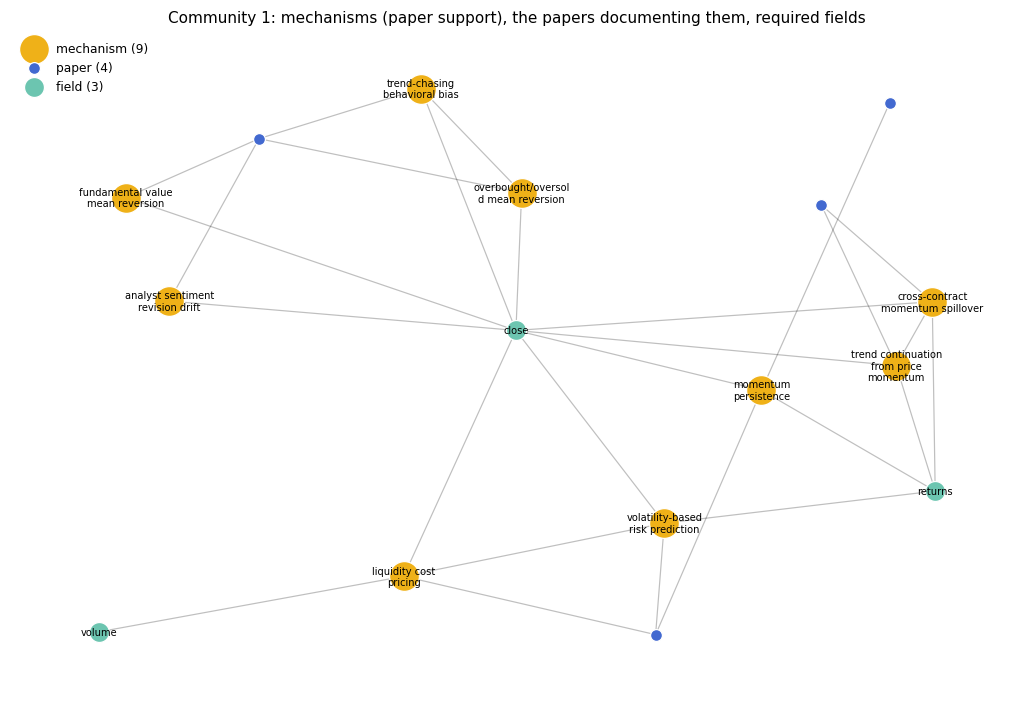

In [7]:
# the neighbourhood we are about to seed from: the group's community, drawn as a graph
import networkx as nx

cid = GROUP["community_id"]
members = communities[cid]
top_mechs = sorted((m for m in members if graph.g.nodes[m].get("type") == "mechanism"),
                   key=lambda m: -len(graph.papers_for_mechanism(m)))[:9]
sub = set(top_mechs)
for m in top_mechs:
    sub.update(graph.papers_for_mechanism(m)[:3])
    sub.update(graph.factors_for_mechanism(m))
    sub.update(graph.fields_needed(m))
H = graph.g.subgraph(sub).to_undirected()

STYLE = {"mechanism": (C_MECH, 380), "paper": (C_PAPER, 60),
         "factor": (C_FACTOR, 240), "field": (C_FIELD, 170)}
pos = nx.spring_layout(H, seed=4, k=0.9)
fig, ax = plt.subplots(figsize=(9.5, 6.5))
for t, (c, s) in STYLE.items():
    nodes = [n for n in H if graph.g.nodes[n].get("type") == t]
    nx.draw_networkx_nodes(H, pos, nodelist=nodes, node_color=c, node_size=s,
                           edgecolors="white", linewidths=0.8, ax=ax,
                           label=f"{t} ({len(nodes)})")
nx.draw_networkx_edges(H, pos, alpha=0.25, width=0.8, ax=ax)
labels = {n: textwrap.fill(graph.g.nodes[n].get("name", n.split(":", 1)[-1]), 18)
          for n in H if graph.g.nodes[n].get("type") in ("mechanism", "field")}
nx.draw_networkx_labels(H, pos, labels, font_size=6.5, ax=ax)
ax.legend(loc="upper left", fontsize=8, frameon=False)
ax.set_title(f"Community {cid}: mechanisms (paper support), the papers documenting them, "
             f"required fields", fontsize=10)
ax.grid(False); ax.set_axis_off()
plt.tight_layout(); plt.show()

## 5 · Seeding one factor — retrieval-grounded brainstorm (live LLM)

Generation 0 turns a group's gap mechanisms into concrete, citable factor ideas. The steps,
all of which we run live below:

1. a **retrieval query** is composed from the run's field scope + the group's focus + its
   gap mechanisms;
2. the embedded corpus returns the top-k papers by cosine similarity (date-gated in real
   runs so no idea can be grounded in a paper published after the data cutoff; scope-gated
   so a price-only run doesn't retrieve fundamentals papers);
3. one brainstorm call receives the papers **in full** plus the data context and must
   *synthesize across at least two of them* (`Nto1` cardinality — where genuinely novel
   combinations come from); each idea must name the mechanism it exploits and declare an
   `expected_sign` and a `prediction_horizon`, both of which are later tested;
4. **citation verification**: any claimed source paper outside the retrieved set is a
   hallucination — the citation is dropped, and an idea with no verifiable grounding is
   discarded.


In [8]:
from quant_fund_agent.knowledge.embed_store import EmbedStore
from quant_fund_agent.knowledge.retrieval import build_query, retrieve_and_brainstorm

t0 = time.time()
store = EmbedStore(); store.build()
print(f"embed store ready in {time.time()-t0:.0f}s ({len(store.docs):,} papers)\n")

query = build_query(DATA_CONTEXT, focus=GROUP["focus"], gaps=GROUP["mechanisms"])
print("RETRIEVAL QUERY " + "─" * 60)
print(query)

papers = store.retrieve_papers(query, k=3, allowed_scopes={"price", "general"})
print("\nRETRIEVED PAPERS " + "─" * 60)
for p in papers:
    print(f"  {p.score:+.3f}  {p.title[:80]}  ({p.published_date}, "
          f"{len(p.text):,} chars of text)")

knowledge.embed_store    embed cache hit: 1723 papers, 12025 chunks


embed store ready in 1s (1,723 papers)

RETRIEVAL QUERY ────────────────────────────────────────────────────────────
quantitative trading alpha factor cross-sectional return prediction
Community 1: 34 mechanism(s) (analyst sentiment revision drift, compounding amplification, cross-channel loading anti-alignment, cross-contract momentum spillover, cross-sectional momentum, cross-sectional momentum signal extraction…) across 12 paper(s). target mechanisms: analyst sentiment revision drift, fundamental value mean reversion, liquidity cost pricing, overbought/oversold mean reversion
underexplored mechanisms: analyst sentiment revision drift, fundamental value mean reversion, liquidity cost pricing, overbought/oversold mean reversion
computable from fields: close, high, low, open, volume



RETRIEVED PAPERS ────────────────────────────────────────────────────────────
  +0.607  Modeling the coupled return-spread high frequency dynamics of large tick assets  (2013-10-16, 1,515 chars of text)
  +0.602  Volatility conditional on price trends  (2005-01-28, 1,475 chars of text)
  +0.597  Hidden Order in Trades Predicts the Size of Price Moves  (2025-12-02, 13,663 chars of text)


In [9]:
from quant_fund_agent.llm import make_chat_llm

brainstorm_llm = make_chat_llm(temperature=0.7, timeout=240, max_retries=3, role="brainstorm")

t0 = time.time()
raw_ideas = retrieve_and_brainstorm(
    brainstorm_llm, store, n_ideas=2, known_ids=set(),
    data_context=GROUP_CONTEXT, cardinality="Nto1", k_papers=3,
    allowed_scopes={"price", "general"},
    focus=GROUP["focus"], gaps=GROUP["mechanisms"], mechanism_tags=GROUP["mechanisms"])
if not raw_ideas:      # every citation failed verification — very rare; retry without
    raw_ideas = retrieve_and_brainstorm(   # the two-paper synthesis constraint
        brainstorm_llm, store, n_ideas=2, known_ids=set(),
        data_context=GROUP_CONTEXT, cardinality="NtoM", k_papers=3,
        allowed_scopes={"price", "general"},
        focus=GROUP["focus"], gaps=GROUP["mechanisms"], mechanism_tags=GROUP["mechanisms"])
assert raw_ideas, "brainstorm returned no verifiable ideas — re-run this cell"
print(f"{len(raw_ideas)} idea(s), citation-verified, in {time.time()-t0:.0f}s\n")

for i, idea in enumerate(raw_ideas):
    print(f"── idea {i} ────────────────────────────────────────────────")
    for k in ("factor_id", "name", "category", "mechanism", "expected_sign",
              "prediction_horizon", "source_paper_ids"):
        print(f"  {k:<18}: {idea.get(k)}")
    print("  trading_idea      :")
    print(wrap(idea.get("trading_idea", ""), indent="      "))
    print()

knowledge.retrieval      retrieved 3 paper(s) [modeling_the_coupled_return_spread_high_frequency_dynamics_o, volatility_conditional_on_price_trends, hidden_order_in_trades_predicts_the_size_of_price_moves] for cardinality=Nto1


/Users/lucawurker/Desktop/Imperial/Master Thesis/QuantFundAgent/venv/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


2 idea(s), citation-verified, in 25s

── idea 0 ────────────────────────────────────────────────
  factor_id         : structured_flow_trend_continuation
  name              : Structured Flow Trend Continuation
  category          : microstructure
  mechanism         : liquidity cost pricing
  expected_sign     : None
  prediction_horizon: 5
  source_paper_ids  : ['hidden_order_in_trades_predicts_the_size_of_price_moves', 'volatility_conditional_on_price_trends', 'modeling_the_coupled_return_spread_high_frequency_dynamics_o']
  trading_idea      :
      Persistent, unusually predictable price-volume sequences are a daily-bar proxy for
      concentrated meta-order execution: a sequence of similarly signed returns accompanied by
      similarly unusual volume is less likely to be random liquidity trading. The entropy paper
      motivates low transition entropy as a state of structured trading activity, while the
      trend-volatility result identifies aligned non-overlapping returns a

Below is the **actual prompt** the brainstorm call sent (start and end — the middle is the
full text of the retrieved papers) and the start of the model's raw reply, read back from
the transcript. This is the entire input the idea generation gets: papers, data contract,
group focus, mechanism-tagging instruction, and a strict JSON schema.

In [10]:
rows = [json.loads(l) for l in open(os.environ["QF_LLM_TRANSCRIPT_PATH"])]
call = next((r for r in reversed(rows) if r.get("role") == "brainstorm"), rows[-1])
prompt, reply = call["prompt"], call["response"]
print(f"model={call['model']}  prompt={call['input_tokens']:,} tok  "
      f"reply={call['output_tokens']:,} tok\n")
print("PROMPT (first 1,600 chars) " + "─" * 50)
print(prompt[:1600])
print("\n   [... full text of the retrieved papers ...]\n")
print("PROMPT (last 1,200 chars) " + "─" * 51)
print(prompt[-1200:])
print("\nRAW REPLY (first 900 chars) " + "─" * 49)
print(reply[:900])

model=gpt-5.6-terra  prompt=5,769 tok  reply=1,801 tok

PROMPT (first 1,600 chars) ──────────────────────────────────────────────────
You are a senior quantitative researcher at a systematic trading firm.
Your job in this session is to invent 2 new alpha factor(s)
that complement an existing seed ensemble.

DATA CONTEXT
------------
You are working with the configured market-data feed (daily bars).  When you write a factor, the ``data``
dict passed to ``calc`` exposes the fields below as ``pd.DataFrame``
(index = bar timestamps, columns = tickers).  Every field below is
available — pick whichever ones your idea actually needs; do NOT use any
field that is not listed (the factor would be rejected as out-of-scope).

Price / OHLCV view:

    open      : start-of-bar price (mid-price on LOBSTER)
    high      : intra-bar high (max(mid, midEnd) on LOBSTER)
    low       : intra-bar low (min(mid, midEnd) on LOBSTER)
    close     : end-of-bar price (mid-price on LOBSTER)
    volume    : trad

## 6 · Codegen — idea → validated factor program (live LLM)

A second, lower-temperature call turns the chosen idea into code. The contract is strict: one
`BaseFactor` subclass, declared `inputs` covering every field it reads, a declared
`prediction_horizon`, causal operators only (trailing windows, positive lags, no fitting
inside `calc`), and a whitelisted import set. The result is compiled **in-memory** and
smoke-tested on a synthetic panel — a candidate only ever becomes a file if it survives the
whole selection process. A failed validation is fed back to the model once, verbatim, for a
single repair attempt; after that the idea is dropped.

In [11]:
from quant_fund_agent.agents.factor_research.evolution.loop import _codegen_program, coerce_idea
from quant_fund_agent.agents.factor_research.graph import _codegen_prompt

idea = coerce_idea(raw_ideas[0], HORIZON, force_horizon=True)
cg_prompt = _codegen_prompt(idea, GROUP_CONTEXT)
print(f"codegen prompt: {len(cg_prompt):,} chars (idea + data contract + operator "
      f"reference + a worked example factor + the validator's rules)\n")
print(cg_prompt[:1500])
print("\n   [...]")

codegen prompt: 18,826 chars (idea + data contract + operator reference + a worked example factor + the validator's rules)

You are writing production Python for a quant trading firm.

You will produce the full source of ONE factor file, ready to be
saved as ``quant_fund_agent/factors/researcher/structured_flow_trend_continuation.py``.

DATA CONTEXT
------------
You are working with the configured market-data feed (daily bars).  When you write a factor, the ``data``
dict passed to ``calc`` exposes the fields below as ``pd.DataFrame``
(index = bar timestamps, columns = tickers).  Every field below is
available — pick whichever ones your idea actually needs; do NOT use any
field that is not listed (the factor would be rejected as out-of-scope).

Price / OHLCV view:

    open      : start-of-bar price (mid-price on LOBSTER)
    high      : intra-bar high (max(mid, midEnd) on LOBSTER)
    low       : intra-bar low (min(mid, midEnd) on LOBSTER)
    close     : end-of-bar price (mid-price on

In [12]:
codegen_llm = make_chat_llm(temperature=0.2, timeout=240, max_retries=3, role="codegen")

t0 = time.time()
prog = _codegen_program(codegen_llm, idea, GROUP_CONTEXT, expected_prediction_horizon=HORIZON)
if prog is None:
    raise RuntimeError("codegen failed validation twice — re-run this cell (fresh sample)")
print(f"compiled + smoke-tested in {time.time()-t0:.0f}s: {prog.factor_id} "
      f"(horizon {prog.prediction_horizon}, expected_sign {prog.expected_sign})\n")
print(prog.code)

compiled + smoke-tested in 12s: structured_flow_trend_continuation (horizon 6, expected_sign None)

"""Persistent, unusually predictable price-volume sequences are a daily-bar proxy for concentrated meta-order execution: a sequence of similarly signed returns accompanied by similarly unusual volume is less likely to be random liquidity trading. The entropy paper motivates low transition entropy as a state of structured trading activity, while the trend-volatility result identifies aligned non-overlapping returns as a regime in which price movement and volatility reinforce each other. The trade is in the direction of the structured move because institutions commonly split orders across days and liquidity providers widen effective trading costs rather than immediately absorbing the full imbalance. The hypothesis is falsified if low-entropy, high-volume directional sequences have no more subsequent same-sign return than matched high-entropy sequences after controlling for volatility and r

## 7 · Scoring — the deterministic harness (no LLM anywhere in here)

The reward channel. The dev window is split IS/VAL in time (60/20 here; the last 20% is a
TEST tail the search never touches). The candidate is scored **against a book**: in a real
run that book is the run's own evolving Pareto archive plus an optional fixed reference
book; here I pre-load 8 of the Kakushadze "101 formulaic alphas" (the same fixed book the
thesis matrix uses, restricted to OHLCV-computable members) so the marginal-value axis has
something meaningful to beat from the first candidate.

Alongside the candidate, the harness receives two **window-jittered probes** — the same
program with every window constant scaled ×0.9 / ×1.1, generated by AST rewrite, no LLM.
These feed the plateau penalty in the next section: a real effect should survive a ±10%
change of its windows.

Everything below is one call: `evaluate_fitness(candidate, book, jitter_probes, ...)`.

In [13]:
from quant_fund_agent.mcp import research_client
from quant_fund_agent.agents.factor_research.evolution.mutation import jitter_variants

prebook = json.load(open(ROOT / "data/prebooks/formulaic_101.json"))
_ohlcv = set(FIELDS)
FIXED_BOOK = [e for e in prebook["members"]
              if set(re.findall(r"data\[['\"](\w+)['\"]\]", e["code"])) <= _ohlcv][:8]
print("fixed conditioning book:", ", ".join(b["factor_id"] for b in FIXED_BOOK))

probes = [{"factor_id": pid, "code": c} for pid, c in jitter_variants(prog, (0.9, 1.1))]
print(f"jitter probes: {[p['factor_id'] for p in probes]}\n")

t0 = time.time()
res = research_client.evaluate_fitness(
    candidate={"factor_id": prog.factor_id, "code": prog.code,
               "expected_sign": prog.expected_sign},
    book=[{"factor_id": b["factor_id"], "code": b["code"]} for b in FIXED_BOOK],
    jitter=probes,
    target_horizon=HORIZON, is_frac=0.6, val_frac=0.2, n_trials=1,
    data_dir=DATA_DIR, n_tickers=N_TICKERS, fields=FIELDS,
    independence_metric="residual_ic", marginal_model="lightgbm")
print(f"scored in {time.time()-t0:.0f}s (first call pays the panel + signal warm-up)  "
      f"|  ok = {res['ok']}")
if not res.get("ok"):
    raise RuntimeError(res.get("error"))

fit  = res["fitness"]
obj, gates, diag = fit["objective"], fit["gates"], fit["diagnostics"]

print("\nPARETO OBJECTIVE VECTOR (all four maximised jointly)")
print(f"  marginal_value     : {fmt(obj['marginal_value'])}")
print(f"  independence       : {fmt(obj['independence'])}")
print(f"  parsimony          : {fmt(obj['parsimony'], 1)}")
print(f"  structural_novelty : {fmt(obj['structural_novelty'], 3)}")
print(f"\nHARD GATES: passed = {gates['passed']}  "
      f"({', '.join(g + '=' + str(gates[g]) for g in ('coverage_ok', 'deflation_ok', 'cost_ok'))})")
for k, v in (gates.get("reasons") or {}).items():
    print(f"    x {k}: {v}")

fixed conditioning book: alpha_001, alpha_002, alpha_003, alpha_004, alpha_005, alpha_006, alpha_007, alpha_008
jitter probes: ['structured_flow_trend_continuation_jit0', 'structured_flow_trend_continuation_jit1']

research.service         Loading panel from ticker_data (fields=['close', 'high', 'low', 'open', 'volume'], n_tickers=20) …


data.cache               cache: 0/20 symbols hit, fetching 20 from yfinance


research.service         Panel loaded in 0.7s (20 tickers, 5 fields)


scored in 4s (first call pays the panel + signal warm-up)  |  ok = True

PARETO OBJECTIVE VECTOR (all four maximised jointly)
  marginal_value     : -0.0072
  independence       : +0.0072
  parsimony          : -182.0
  structural_novelty : +0.964

HARD GATES: passed = True  (coverage_ok=True, deflation_ok=None, cost_ok=None)


## 8 · The four Pareto axes, one at a time

Selection is multi-objective (constrained NSGA-II): a candidate survives if it is
*non-dominated* on the vector, so a factor can buy its place with any one axis — the search
does not collapse everything into a single score. The four axes, and exactly how each is
computed:

### 8.1 `marginal_value` — does the *book* get better? (primary axis)

Not the factor's own IC. A combined model (LightGBM here — nonlinear on purpose, so
*conditioning* factors whose value lives in interactions are seen) is fit on the book's
standardised signals over IS rows and scored as an information coefficient on VAL. It is
fit twice: **without** and **with** the candidate. The raw axis ingredient is the
leave-one-candidate-out delta `ΔIC = IC_with − IC_without`. Two docks and one bonus are
then folded in, all on IC scale:

- **plateau penalty** — the candidate is re-scored with all window constants ×0.9 / ×1.1
  (the AST-jittered probes from above); edge that dies under a ±10% window change is
  docked as knife-edge;
- **perturbation penalty** — an optional probe that shocks the signal with noise (off by
  default, off here);
- **sign bonus** — a small ± for the declared `expected_sign` being confirmed/contradicted
  by the realised IC sign: the hypothesis was a *prediction*, and it gets tested.

In [14]:
raw_mv  = diag.get("marginal_value_raw")
plateau = diag.get("plateau_penalty") or 0.0
pert    = diag.get("perturbation_penalty") or 0.0
sign_ok = diag.get("sign_consistency")
axis    = obj["marginal_value"]
sign_bonus = (axis - (raw_mv - plateau - pert)) if (axis is not None and raw_mv is not None) else None

print(f"combined-model OOS IC, book only      : {fmt(diag.get('base_ic'))}")
print(f"combined-model OOS IC, book+candidate : {fmt(diag.get('with_ic'))}")
print(f"raw LOCO ΔIC                          : {fmt(raw_mv)}")
print(f"  − plateau penalty (window jitter)   : {fmt(plateau)}")
print(f"  − perturbation penalty              : {fmt(pert)}")
print(f"  ± sign bonus (hypothesis {'confirmed' if sign_ok else 'contradicted' if sign_ok is False else 'untested'})  : {fmt(sign_bonus)}")
print(f"  = marginal_value axis               : {fmt(axis)}")
print(f"\ncandidate VAL IC at window scales 0.9x / 1.1x: "
      f"{[round(x, 4) if x is not None else None for x in diag.get('jitter_ics', [])]}"
      f"   (unjittered VAL IC: {fmt(diag.get('val_ic'))})")

combined-model OOS IC, book only      : +0.0228
combined-model OOS IC, book+candidate : +0.0156
raw LOCO ΔIC                          : -0.0072
  − plateau penalty (window jitter)   : +0.0000
  − perturbation penalty              : +0.0000
  ± sign bonus (hypothesis untested)  : +0.0000
  = marginal_value axis               : -0.0072

candidate VAL IC at window scales 0.9x / 1.1x: [0.0033, 0.0061]   (unjittered VAL IC: -0.0044)


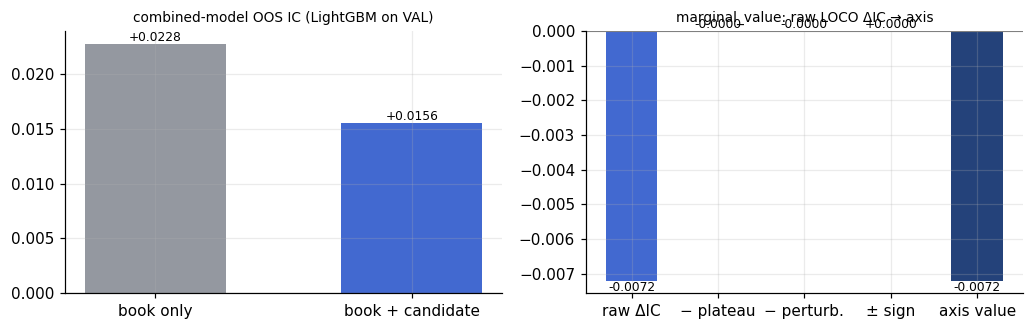

In [15]:
if raw_mv is not None and axis is not None:
    fig, axes_ = plt.subplots(1, 2, figsize=(9.5, 3.1))

    a = axes_[0]
    vals = [diag.get("base_ic"), diag.get("with_ic")]
    a.bar(["book only", "book + candidate"], vals, color=[C_MUTED, C_MAIN], width=0.55)
    for i, v in enumerate(vals):
        if v is not None:
            a.annotate(f"{v:+.4f}", (i, v), ha="center",
                       va="bottom" if v >= 0 else "top", fontsize=8)
    a.axhline(0, color="grey", lw=0.7)
    a.set_title("combined-model OOS IC (LightGBM on VAL)", fontsize=9)

    a = axes_[1]
    parts  = [raw_mv, -plateau, -pert, sign_bonus or 0.0, axis]
    names  = ["raw ΔIC", "− plateau", "− perturb.", "± sign", "axis value"]
    colors = [C_MAIN, C_MUTED, C_MUTED, C_MUTED, "#24427a"]
    a.bar(names, parts, color=colors, width=0.6)
    for i, v in enumerate(parts):
        a.annotate(f"{v:+.4f}", (i, v), ha="center",
                   va="bottom" if v >= 0 else "top", fontsize=8)
    a.axhline(0, color="grey", lw=0.7)
    a.set_title("marginal_value: raw LOCO ΔIC → axis", fontsize=9)
    plt.tight_layout(); plt.show()
else:
    print("marginal value not computable on this window (too few observations)")

### 8.2 `independence` — edge the book does not already span

Correlation alone is the wrong redundancy test. The candidate's signal is regressed on the
book's signals (betas fit on IS only — factor formulas have no fitted parameters, so only
the betas are estimated), and the **residual** is correlated with forward returns over
IS∪VAL. That residual IC is the axis: predictive content orthogonal to everything the book
already has. A factor can be 0.7-correlated with the book and still carry genuine residual
edge — and a zero-marginal candidate with high residual IC is exactly the "useful later"
diversity NSGA-II keeps alive.

In [16]:
print(f"standalone VAL IC          : {fmt(diag.get('standalone_ic'))}   "
      f"(IS {fmt(diag.get('is_ic'))}, VAL {fmt(diag.get('val_ic'))})")
print(f"residual IC (the axis)     : {fmt(diag.get('residual_ic'))}   on IS∪VAL, "
      f"betas fit on IS only")
print(f"max |corr| to a book factor: {fmt(diag.get('max_abs_corr'))}")
print(f"book effective factors     : {fmt(diag.get('pr_before'), 2)} → "
      f"{fmt(diag.get('pr_after'), 2)}  (participation ratio, diagnostic)")

standalone VAL IC          : -0.0044   (IS +0.0059, VAL -0.0044)
residual IC (the axis)     : +0.0072   on IS∪VAL, betas fit on IS only
max |corr| to a book factor: +0.5646
book effective factors     : +6.58 → +6.36  (participation ratio, diagnostic)


### 8.3 `parsimony` — minus structural complexity

Simply `−(operator + constant count)` of the factor's canonical AST. Formula bloat is the
classic overfitting vector in evolved alphas (both in GP mining and in LLM loops — models
happily bolt on one more conditioning branch to buy in-sample IC), so complexity is priced
directly into selection rather than policed by a hard cap.

### 8.4 `structural_novelty` — is this actually a new computation?

The distance of the candidate's **canonical AST** to its nearest neighbour in the archive
(falling back to the fixed book when the archive is empty). Canonicalisation strips
docstrings and variable names, alpha-renames, inlines trivial temporaries, reorders
commutative operands — and replaces **numeric literals with typed placeholders**, so a
20-bar vs 21-bar window is the *same* factor. Every subtree is fingerprinted and two
programs are compared by weighted multiset Jaccard over subtree fingerprints: 0 = structural
clone, 1 = no shared subtree. Re-tuning constants therefore cannot register as novelty —
the axis only rewards genuinely different computations. Demonstration:

In [17]:
from quant_fund_agent.research_eval.ast_novelty import ast_subtree_distance

d_jitter = ast_subtree_distance(prog.code, probes[0]["code"])       # windows ×0.9
d_book   = ast_subtree_distance(prog.code, FIXED_BOOK[3]["code"])   # a different alpha

print(f"distance(candidate, its ×0.9-window jitter) : {d_jitter:.3f}   ← a clone, as it should be")
print(f"distance(candidate, {FIXED_BOOK[3]['factor_id']})              : {d_book:.3f}")
print(f"\naxis value (min distance to book): {fmt(obj['structural_novelty'], 3)}   "
      f"(nearest: book member #{diag.get('novelty_nearest_book_idx')}, "
      f"{diag.get('novelty_candidate_ast_nodes')} AST nodes, "
      f"{diag.get('novelty_candidate_unique_subtrees')} unique subtrees)")

distance(candidate, its ×0.9-window jitter) : 0.000   ← a clone, as it should be
distance(candidate, alpha_004)              : 0.986

axis value (min distance to book): +0.964   (nearest: book member #6, 317 AST nodes, 197 unique subtrees)


### The gates, and where deflation lives

Two things sit *outside* the vector. **Hard gates** are feasibility, not quality: coverage
(the signal must price enough of the panel) and an optional turnover/cost gate. A gated-out
candidate can still be selected as a parent-of-last-resort but cannot enter the book.

**Multiple-testing deflation is deliberately a *publish* filter, not a search gate.** Every
scored candidate increments the run's `N_trials`; at materialise time the book's combined
statistic is deflated for the full search effort (Bailey/López-de-Prado style luck
haircut), and factors that don't survive it are pruned. Putting the haircut inside the
search loop would just teach the search to farm the statistic; billing it once at the end
keeps the honesty control outside the optimisation.

In [18]:
defl = diag.get("deflation") or {}
print(f"gates: {gates}")
print(f"\ndeflation diagnostics at n_trials={diag.get('n_trials')}: "
      f"deflated t = {fmt(defl.get('deflated_t'), 2)}, "
      f"luck haircut on |IC| = {fmt(defl.get('luck_ic'))}")
print(f"coverage: {fmt(diag.get('coverage'), 3)} of (date,ticker) cells priced")

gates: {'coverage_ok': True, 'deflation_ok': None, 'cost_ok': None, 'passed': True}

deflation diagnostics at n_trials=1: deflated t = +0.45, luck haircut on |IC| = +0.0000
coverage: +1.000 of (date,ticker) cells priced


## 9 · Reflection — the deterministic teacher

This is the piece I would most like you to read closely, because it is where the design
keeps the loop honest. The evaluation above must reach the LLM somehow — but if an LLM
*wrote* the feedback, the system would be grading its own homework and could drift into
flattery or self-reinforcement. So the **mutation brief** is rendered by fixed rules from
the diagnostics dict: every sentence is triggered by a numeric condition, identical numbers
always produce the identical brief, and the numbers quoted are out-of-sample statistics —
the model sees *how* the candidate failed, never the data it failed on. This brief is the
complete "experience" the next generation inherits.

In [19]:
from quant_fund_agent.research_eval.fitness import FitnessResult
from quant_fund_agent.agents.factor_research.evolution.reflection import mutation_brief

fitness = FitnessResult.from_dict(fit)
brief = mutation_brief(fitness, book_size=len(FIXED_BOOK))
print(brief)

VERDICT: passed every hard gate; competing on the Pareto front.
Marginal value (primary axis): adding this factor moved the combined model's OOS IC by -0.0072 (with=+0.0156, book-only=+0.0228, book size=8).
Standalone IC at the target horizon: -0.0044 (IS=+0.0059, VAL=-0.0044).
IC decay across horizons: 1b=+0.0026, 3b=-0.0014, 6b=-0.0044, 12b=-0.0014, 24b=-0.0240.  |IC| peaks at 24 bars (-0.0240).
Independence (axis = residual_ic): residual IC after regressing out the book +0.0072 — the edge the book does NOT already span; Δ participation ratio -0.2216 (book effective factors +6.58 → +6.36); max |corr| to an existing factor: +0.5646.
Structural novelty (4th axis): canonical AST weighted-subtree distance to nearest archive member +0.9635 (book=+0.9635, zoo=n/a) — 0 = structural clone (same canonical computation), 1 = no shared canonical subtree.
Parameter sensitivity: jittering the window constants ±10% moved the VAL IC to ['+0.0033', '+0.0061'] — plateau penalty +0.0000.
Complexity (op

## 10 · Mutation — one evolution step (live LLM)

The creative operator. The prompt hands the model the parent's hypothesis, its full code,
the reflection brief verbatim, the group's mechanism focus, and the same strict codegen
contract — and asks for **one child that addresses the report's weaknesses**. The child may
change the mechanism (that is what separates *mutation* from the `refine` ablation, which
pins it). In a real run this operator competes with LLM crossover (two parents, synthesis
required), deterministic window-jitter, and the rare cross-group synthesis.

In [20]:
from quant_fund_agent.agents.factor_research.evolution.mutation import (
    build_mutation_prompt, parse_child_response,
)
from quant_fund_agent.factors.inmem import compile_factor

existing_ids = [prog.factor_id] + [b["factor_id"] for b in FIXED_BOOK]
mut_prompt = build_mutation_prompt(prog, brief, GROUP_CONTEXT, existing_ids=existing_ids)

i = mut_prompt.find("CURRENT VERSION")
j = mut_prompt.find("EXISTING FACTOR IDS")
print(f"mutation prompt: {len(mut_prompt):,} chars.  The section the model actually "
      f"reacts to —\n")
print(mut_prompt[i:j])

mutation prompt: 25,566 chars.  The section the model actually reacts to —




In [21]:
t0 = time.time()
child = None
for attempt in range(3):     # a malformed reply is rejected and re-sampled — in the
    resp = brainstorm_llm.invoke(mut_prompt)   # real loop a failed proposal just costs
    try:                                       # the operator its slot, never the run
        child = parse_child_response(getattr(resp, "content", str(resp)))
        compile_factor(child.code, child.factor_id, smoke=True)
        break
    except Exception as e:
        print(f"attempt {attempt + 1}: child rejected ({str(e)[:90]}) — re-sampling")
        child = None
assert child is not None, "mutation failed three times — re-run this cell"
print(f"child proposed + validated in {time.time()-t0:.0f}s\n")
print(f"PARENT  {prog.factor_id}")
print(wrap(prog.trading_idea or prog.description, indent="    "))
print(f"\nCHILD   {child.factor_id}  (horizon {child.prediction_horizon}, "
      f"expected_sign {child.expected_sign})")
print(wrap(child.trading_idea or child.description, indent="    "))
print("\n" + child.code)

attempt 1: child rejected (syntax error: unexpected character after line continuation character (<unknown>, line 1)) — re-sampling


child proposed + validated in 53s

PARENT  structured_flow_trend_continuation
    Persistent, unusually predictable price-volume sequences are a daily-bar proxy for
    concentrated meta-order execution: a sequence of similarly signed returns accompanied by
    similarly unusual volume is less likely to be random liquidity trading. The entropy paper
    motivates low transition entropy as a state of structured trading activity, while the trend-
    volatility result identifies aligned non-overlapping returns as a regime in which price
    movement and volatility reinforce each other. The trade is in the direction of the
    structured move because institutions commonly split orders across days and liquidity
    providers widen effective trading costs rather than immediately absorbing the full
    imbalance. The hypothesis is falsified if low-entropy, high-volume directional sequences
    have no more subsequent same-sign return than matched high-entropy sequences after
    controlling 

In [22]:
# score the child exactly like the parent (n_trials=2: the search is billed per look)
child_probes = [{"factor_id": pid, "code": c} for pid, c in jitter_variants(child, (0.9, 1.1))]
res_c = research_client.evaluate_fitness(
    candidate={"factor_id": child.factor_id, "code": child.code,
               "expected_sign": child.expected_sign},
    book=[{"factor_id": b["factor_id"], "code": b["code"]} for b in FIXED_BOOK],
    jitter=child_probes,
    target_horizon=HORIZON, is_frac=0.6, val_frac=0.2, n_trials=2,
    data_dir=DATA_DIR, n_tickers=N_TICKERS, fields=FIELDS,
    independence_metric="residual_ic", marginal_model="lightgbm")
assert res_c["ok"], res_c.get("error")
fit_c = res_c["fitness"]

def row(f):
    o, d = f["objective"], f["diagnostics"]
    return {"marginal_value": o["marginal_value"], "independence": o["independence"],
            "parsimony": o["parsimony"], "structural_novelty": o["structural_novelty"],
            "VAL IC": d.get("val_ic"), "residual IC": d.get("residual_ic"),
            "plateau pen.": d.get("plateau_penalty"), "gates": f["gates"]["passed"]}

cmp_df = pd.DataFrame({"parent": row(fit), "child": row(fit_c)}).T
cmp_df.round(4)

research.service         [evaluate_fitness] jitter probe flow_exhaustion_value_reversal_jit0 failed (min_periods 3 must be <= window 2) — skipped


,marginal_value,independence,parsimony,structural_novelty,VAL IC,residual IC,plateau pen.,gates
parent,-0.007202,0.007196,-182.0,0.963535,-0.004419,0.007196,0.0,True
child,0.003408,0.007557,-60.0,0.945709,0.002989,0.007557,0.002337,True


Whether the child improved or not, both now carry a full evaluation — and in the real loop
**both** would enter NSGA-II selection: feasibility first (gate-passers before gate-failers),
then Pareto dominance on the four axes, then crowding distance as the tie-break that keeps
the front spread out. Parents are drawn by tournament from the group's population, the
group archive keeps every non-dominated gate-passer (capped, crowding-culled), and the
accepted book is the union of the group archives. Nothing in that paragraph involves an
LLM — selection is entirely deterministic.

## 11 · A full generation, end to end (live — the expensive cell)

Everything above, wired together and run by the actual `EvolutionLoop`: the graph resolves
mechanism groups (capped at 2 here), each group seeds 3 retrieval-grounded ideas
(generation 0), and then one generation of children is bred — mutation / crossover / jitter
chosen stochastically, every candidate scored against the fixed book + the evolving
archive, admitted by NSGA-II, checkpointed. The trace line printed at each admission shows
the operator, the four axes, and the gate verdict — generation logs in real runs look
exactly like this, for 20 generations and 8 groups.

Expect ~5–10 minutes and (with `gpt-5.6-terra`) around a dollar — metered precisely below.
It is also normal to see a proposal or two rejected in the trace: a malformed reply or a
validator failure costs that operator its slot, never the run.

In [23]:
import shutil
from quant_fund_agent.agents.factor_research.evolution.loop import (
    EvolutionLoop, EvolutionRunConfig,
)

shutil.rmtree(SCRATCH / "demo_run", ignore_errors=True)   # always a fresh demo run

cfg = EvolutionRunConfig(
    generations=1, population_size=6,
    n_mechanism_groups=2, mechanism_groups_mode="max", demes_per_group=1,
    children_per_deme=2, seed_ideas_per_group=3, n_seed_ideas=3,
    retrieval="graphrag", retrieval_cardinality="Nto1", rag_k=3,
    target_horizon=HORIZON, is_frac=0.6, val_frac=0.2,
    independence_metric="residual_ic", marginal_model="lightgbm",
    data_dir=DATA_DIR, n_tickers=N_TICKERS, seed=11, llm_workers=2,
    fixed_book=[{"factor_id": b["factor_id"], "code": b["code"]} for b in FIXED_BOOK],
    graph_readonly=True,                      # do not write provenance into the repo graph
    out_dir=str(SCRATCH / "demo_run"),
)
loop = EvolutionLoop(cfg, data_context=DATA_CONTEXT, fields=FIELDS)
print("groups resolved from the knowledge graph:")
for s in loop.mechanism_groups:
    print(f"  group {s['mechanism_group_id']} (community {s['community_id']}): "
          f"{', '.join(s['mechanisms'][:3]) or '(community focus only)'}")

def attach_trace(lp):
    orig = lp._admit_genome
    def traced(genome):
        eg = orig(genome)
        if eg is None:
            return eg
        o, g = eg.fitness.objective, eg.fitness.gates
        verdict = "PASS" if g.passed else \
            "FAIL:" + next((k for k in g.GATES if getattr(g, k) is False), "?")
        print(f"  gen{genome.generation} grp{genome.mechanism_group_id} "
              f"{genome.operator:<12.12} {','.join(genome.factor_ids)[:36]:<36} "
              f"marg {fmt(o.marginal_value)}  indep {fmt(o.independence)}  "
              f"pars {fmt(o.parsimony, 0):>5}  nov {fmt(o.structural_novelty, 2)}  {verdict}")
        return eg
    lp._admit_genome = traced
    return lp

loop = attach_trace(loop)
u0 = dict(usage_summary()["total"])
t0 = time.time()
summary = loop.run()
u1 = usage_summary()["total"]
print(f"\nfinished in {(time.time()-t0)/60:.1f} min: "
      f"{ {k: summary.get(k) for k in ('generations', 'n_trials', 'population', 'n_eval_failures')} }")

groups resolved from the knowledge graph:
  group 0 (community 1): analyst sentiment revision drift, fundamental value mean reversion, liquidity cost pricing
  group 1 (community 2): asymmetric bid-ask queue dynamics, high-frequency trader inventory management, increasing baseline intensity near maturity


evolution.loop           graphrag group 0 seeding: focus='Community 1: 34 mechanism(s) (analyst sentiment revision drift, compounding amplification, cross-channel loading anti-al' mechanisms=['analyst sentiment revision drift', 'fundamental value mean reversion', 'liquidity cost pricing', 'overbought/oversold mean reversion']


knowledge.embed_store    embed cache hit: 1723 papers, 12025 chunks


knowledge.retrieval      retrieved 3 paper(s) [modeling_the_coupled_return_spread_high_frequency_dynamics_o, volatility_conditional_on_price_trends, hidden_order_in_trades_predicts_the_size_of_price_moves] for cardinality=Nto1


evolution.loop           seeded 3/3 program(s) from 3 idea(s)


...

research.service         [evaluate_fitness] jitter probe exhausted_liquidity_overshoot_repair_jit0 failed (min_periods 5 must be <= window 4) — skipped


  gen1 grp0 llm_semantic exhausted_liquidity_overshoot_repair marg +0.0076  indep   n/a  pars  -104  nov +0.78  PASS


  gen1 grp1 crossover    opening_inventory_wick_restock_timin marg -0.0016  indep -0.0116  pars  -121  nov +0.82  PASS
research.service         [evaluate_fitness] jitter probe coherent_execution_inventory_drift_jit0 failed (min_periods 20 must be <= window 18) — skipped


  gen1 grp1 llm_semantic coherent_execution_inventory_drift   marg +0.0032  indep -0.0038  pars   -56  nov +0.67  PASS
evolution.loop           generation 1: 3/4 children admitted; archive=8; n_trials=9



finished in 4.1 min: {'generations': 1, 'n_trials': 9, 'population': 9, 'n_eval_failures': 0}


In [24]:
rows = []
for eg in loop.controller.archive:
    o = eg.fitness.objective
    rows.append({"factor_id": eg.genome.factor_ids[0],
                 "group": eg.genome.mechanism_group_id, "gen": eg.genome.generation,
                 "operator": eg.genome.operator,
                 "marginal_value": o.marginal_value, "independence": o.independence,
                 "parsimony": o.parsimony, "structural_novelty": o.structural_novelty})
arch_df = (pd.DataFrame(rows)
           .sort_values(["group", "marginal_value"], ascending=[True, False])
           .reset_index(drop=True))
print(f"Pareto archive after 1 generation: {len(arch_df)} member(s) across "
      f"{arch_df['group'].nunique()} group(s); kept-pool (every gate-passer): "
      f"{len(loop.controller.kept_pool)}; n_trials billed: {loop.controller.n_trials}")
arch_df.round(4)

Pareto archive after 1 generation: 8 member(s) across 2 group(s); kept-pool (every gate-passer): 9; n_trials billed: 9


,factor_id,group,gen,operator,marginal_value,independence,parsimony,structural_novelty
0,exhausted_liquidity_overshoot_repair,0,1,llm_semantic,0.0076,NaN,-104.0,0.7820
1,persistent_liquidity_tax_convexity,0,0,seed,-0.0067,-0.0122,-180.0,0.7590
2,entropy_conditioned_revision_ladder,0,0,seed,-0.0070,-0.0199,-189.0,0.9656
3,structured_flow_impact_release,1,0,seed,0.0054,NaN,-152.0,0.7623
4,coherent_execution_inventory_drift,1,1,llm_semantic,0.0032,-0.0038,-56.0,0.6657
5,opening_inventory_wick_restock_timing,1,1,crossover,-0.0016,-0.0116,-121.0,0.8233
6,one_sided_wick_queue_restock,1,0,seed,-0.0026,NaN,-142.0,0.9156
7,gap_flow_inventory_unwind,1,0,seed,-0.0030,NaN,-65.0,0.7798


In [25]:
# what this actually cost, from the per-call meter — and the thesis-scale reference point
spent = {k: u1[k] - u0.get(k, 0) for k in ("calls", "input_tokens", "output_tokens", "cost_usd")}
n_scored = summary.get("n_trials", loop.controller.n_trials)
print(f"this generation: {spent['calls']} LLM calls, "
      f"{spent['input_tokens']:,} in / {spent['output_tokens']:,} out tokens, "
      f"${spent['cost_usd']:.2f}  →  ${spent['cost_usd']/max(1, n_scored):.3f} per scored candidate")
print(f"whole notebook so far: ${u1['cost_usd']:.2f}")

by_role = pd.DataFrame(usage_summary()["by_role"]).T
by_role[["calls", "input_tokens", "output_tokens", "cost_usd"]].round(3)

this generation: 13 LLM calls, 99,609 in / 31,953 out tokens, $0.73  →  $0.081 per scored candidate
whole notebook so far: $0.90


,calls,input_tokens,output_tokens,cost_usd
brainstorm,5.0,38186.0,10938.0,0.260
codegen,7.0,31303.0,17097.0,0.335
crossover,1.0,11477.0,2428.0,0.065
mutation,4.0,41143.0,9288.0,0.242


## 12 · What this machinery produced at thesis scale

The repo carries the full artifacts of `L4_terra_s0`, the main GraphRAG evolution run of
the ablation study: Nasdaq-100 point-in-time panel 2010→2024 (survivorship-bias-free, ~130
PIT fundamental fields), 20 generations, 8 mechanism groups × 3 demes, progressive data
reveal (each generation partly scored on data no earlier selection ever saw), the 101
formulaic alphas as the fixed reference book. Every number below is read from the run's
committed checkpoint — the same `state.json` / `lineage.jsonl` the demo run just wrote to
scratch.

In [26]:
L4 = ROOT / "data/workspaces/fmp_archive_equity_nasdaq100pit/preruns/L4_terra_s0"
man   = json.load(open(L4 / "manifest.json"))
use   = json.load(open(L4 / "evolution/llm_usage.json"))
state = json.load(open(L4 / "evolution/state.json"))

print(f"model {man['llm_model']}  |  {man['generations']} generations  |  "
      f"{man['n_trials']} scored candidates  |  {man['n_factors']} factors published  |  "
      f"LLM cost ${use['total']['cost_usd']:.2f}")

rows = []
for gi, arch in enumerate(state["group_archives"]):
    for eg in arch:
        o = eg["fitness"]["objective"]
        p = eg["genome"]["programs"][0]
        rows.append({"factor_id": p["factor_id"], "group": gi,
                     "born_gen": eg["genome"]["generation"],
                     "operator": eg["genome"]["operator"],
                     "marginal_value": o["marginal_value"],
                     "independence": o["independence"], "parsimony": o["parsimony"],
                     "structural_novelty": o["structural_novelty"]})
l4_df = pd.DataFrame(rows)
print(f"\nfinal Pareto archives: {len(l4_df)} members across "
      f"{l4_df['group'].nunique()} mechanism groups; operators: "
      f"{l4_df['operator'].value_counts().to_dict()}")
l4_df.sort_values("marginal_value", ascending=False).head(10).round(4)

model gpt-5.6-terra  |  20 generations  |  798 scored candidates  |  44 factors published  |  LLM cost $86.70

final Pareto archives: 44 members across 8 mechanism groups; operators: {'llm_semantic': 28, 'jitter': 5, 'cross_group': 4, 'llm_semantic_creative': 4, 'crossover': 2, 'seed': 1}


,factor_id,group,born_gen,operator,marginal_value,independence,parsimony,structural_novelty
3,stale_surprise_fear_state_cascade_diffusion,0,16,cross_group,0.0357,None,-317.0,0.8459
14,surprise_rupture_opposing_flow_release,3,3,cross_group,0.0276,None,-188.0,0.9439
30,earnings_downside_auction_persistence_gate,5,17,crossover,0.0113,None,-180.0,0.8595
41,earnings_turnover_impedance_resolution,7,12,llm_semantic_creative,0.0109,None,-97.0,0.8259
28,endogenous_sell_cluster_relaxation,5,13,llm_semantic,0.0065,None,-70.0,0.7541
37,consumption_tail_semibeta_buffered_derisking,6,17,llm_semantic,0.0064,None,-71.0,0.7926
31,participation_weighted_downside_kernel_release,5,17,llm_semantic,0.0061,None,-49.0,0.7961
11,peer_hawkes_contagion_underreaction,2,3,llm_semantic,0.0045,None,-106.0,0.7926
4,coherent_surprise_response_gap_drift,0,17,llm_semantic,0.0044,None,-66.0,0.8477
33,earnings_disambiguated_sector_liquidity_repair_j,5,20,jitter,0.0042,None,-312.0,0.8892


### Two survivors, close up

**`peer_hawkes_contagion_underreaction`** is the factor I would single out: a
Hawkes-process-inspired measure of order-flow contagion between economically related names,
born in generation 3 as an `llm_semantic` mutation of a seeded quality-defence idea — i.e.
the mechanism *changed* along the lineage, which is exactly what the mutation operator is
allowed to do. On the post-run cross-book analysis it is the most stable factor of the
whole Terra book out-of-sample: per-underlying pooled IC ≈ 0.036 on the search window,
**0.029 on the never-revealed TEST window and 0.037 on the two-year forward reserve the run
never touched** — essentially no in-sample-to-forward decay.

In [27]:
FID = "peer_hawkes_contagion_underreaction"

db = json.load(open(L4 / "factors/factor_db.json"))
rec = next(r for r in db["factors"] if r["id"] == FID)
entry = next((eg for arch in state["group_archives"] for eg in arch
              for p in eg["genome"]["programs"] if p["factor_id"] == FID), None)
prog_l4 = next(p for p in entry["genome"]["programs"] if p["factor_id"] == FID)

lineage = [json.loads(l) for l in open(L4 / "evolution/lineage.jsonl")]
birth = next(r for r in lineage
             if FID in r.get("factor_ids", []) and r.get("event") is None)

print(f"category {rec['category']}  |  born gen {birth['generation']} "
      f"({birth['operator']}, group {birth['mechanism_group_id']})  |  "
      f"parent lineage: {birth['parent_ids']}")
print("\nhypothesis:")
print(wrap(rec["trading_idea"], indent="  "))
o = entry["fitness"]["objective"]; d = entry["fitness"]["diagnostics"]
print(f"\nfinal Pareto vector: marginal {fmt(o['marginal_value'])}, "
      f"independence {fmt(o['independence'])}, parsimony {fmt(o['parsimony'], 0)}, "
      f"novelty {fmt(o['structural_novelty'], 2)}")
print(f"diagnostics: VAL IC {fmt(d.get('val_ic'))}, residual IC {fmt(d.get('residual_ic'))}, "
      f"max|corr| to book {fmt(d.get('max_abs_corr'))}, coverage {fmt(d.get('coverage'), 2)}")

category microstructure  |  born gen 3 (llm_semantic, group 2)  |  parent lineage: ['g0-synchrony_gated_quality_defense-b3f539']

hypothesis:
  Institutional order flow often propagates across economically related names over several daily
  bars: a large, signed, volume-supported move in peer firms raises the conditional probability
  of subsequent same-direction flow in a lagging constituent. The factor approximates this
  cross-excitation with an exponentially decayed signed-flow intensity, then buys names whose
  own intensity lags a strongly positive leave-one-out sector intensity and shorts the converse.
  The edge should persist because execution is fragmented across funds, liquidity differs by
  constituent, and sector ETF/index demand is not instantaneously transmitted into every stock;
  it is falsified if peer-flow gaps do not predict same-direction six-bar returns after sector
  demeaning.

final Pareto vector: marginal +0.0045, independence   n/a, parsimony -106, novelty +0

In [28]:
print(prog_l4["code"])

"""Peer-flow Hawkes contagion underreaction.

Mechanism: signed, volume-supported price moves are marks of latent institutional
order flow.  When such marks cluster among a stock's sector peers, an
exponentially decayed Hawkes-style intensity proxies for cross-excitation of
remaining orders.  A constituent whose own intensity has not caught up to a
strong leave-one-out peer intensity should subsequently move in the peer-flow
direction, while an overshooting constituent is expected to correct.
"""

from __future__ import annotations

import numpy as np
import pandas as pd

from quant_fund_agent.factors.base import BaseFactor
from quant_fund_agent.factors.ops import rank
from quant_fund_agent.factors.registry import register_factor


def _exp_flow_intensity(events: pd.DataFrame, half_life: float) -> pd.DataFrame:
    """Causal exponentially decayed marked-event intensity.

    This is the discrete-time conditional-intensity recursion corresponding to
    an exponential Hawkes kernel with

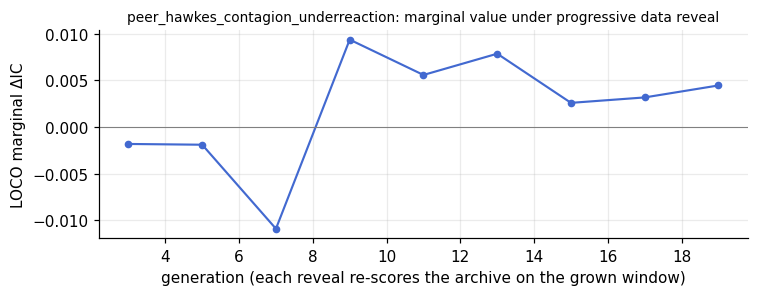

In [29]:
# its LOCO marginal value, re-scored after every progressive reveal of new data —
# the factor was admitted once but had to keep earning its place as the window grew
gid = birth["genome_id"]
drift = [(birth["generation"], birth["objective"]["marginal_value"])]
drift += [(r["generation"], r["objective_after"]["marginal_value"]) for r in lineage
          if r.get("event") == "rescore" and r.get("genome_id") == gid
          and r["objective_after"].get("marginal_value") is not None]
if len(drift) > 1:
    gens, vals = zip(*sorted(drift))
    fig, ax = plt.subplots(figsize=(7, 2.8))
    ax.plot(gens, vals, marker="o", ms=4, lw=1.4, color=C_MAIN)
    ax.axhline(0, color="grey", lw=0.7)
    ax.set_xlabel("generation (each reveal re-scores the archive on the grown window)")
    ax.set_ylabel("LOCO marginal ΔIC")
    ax.set_title(f"{FID}: marginal value under progressive data reveal", fontsize=9)
    plt.tight_layout(); plt.show()

The second one worth a look, **`nonlinear_downside_coskew_compensation_h6`**, prices
compensation for *nonlinear downside co-movement* — TEST IC 0.034, the second-strongest
Terra factor out-of-sample. Its `_h6` suffix is a tell: the id collided with an earlier
candidate in the run and was auto-renamed — the dedup fingerprint is id-masked, so a genuine
structural clone would have been rejected outright; this one differed.

In [30]:
FID2 = "nonlinear_downside_coskew_compensation_h6"
rec2 = next(r for r in db["factors"] if r["id"] == FID2)
entry2 = next((eg for arch in state["group_archives"] for eg in arch
               for p in eg["genome"]["programs"] if p["factor_id"] == FID2), None)
print("hypothesis:")
print(wrap(rec2["trading_idea"], indent="  "))
if entry2 is not None:
    o2 = entry2["fitness"]["objective"]
    print(f"\nfinal Pareto vector: marginal {fmt(o2['marginal_value'])}, "
          f"independence {fmt(o2['independence'])}, parsimony {fmt(o2['parsimony'], 0)}, "
          f"novelty {fmt(o2['structural_novelty'], 2)}")

hypothesis:
  Heavy-tailed consumption-growth risk implies that investors require compensation for stocks
  whose losses become disproportionately severe in broad market downside-tail states, beyond
  their ordinary linear market beta. This child estimates that nonlinear downside exposure from
  trailing daily returns and ranks stocks by their residual loss loading during market-tail
  observations. The premium can persist because crash-state risk is difficult for arbitrageurs
  to warehouse and is especially unattractive to investors with leveraged or consumption-
  sensitive liabilities; the hypothesis is falsified if high residual downside-tail loading does
  not precede higher six-bar returns after controlling for ordinary beta.

final Pareto vector: marginal -0.0096, independence   n/a, parsimony -54, novelty +0.81


The thesis runs are launched with the same code this notebook imported, e.g.:

```bash
./venv/bin/python run_factor_evolution.py --name demo_run \
    --retrieval graphrag --mechanism-groups 8 --mechanism-groups-mode max \
    --demes-per-group 3 --children-per-deme 2 --seed-ideas-per-group 12 \
    --generations 20 --archive-cap 40 --marginal-model lightgbm \
    --progressive-reveal --wf-blocks 10 --graph-readonly --max-cost-usd 120
```

Design documents, if you want the full rationale: `docs/research-evolution/DESIGN.md` (the
loop), `FINAL_RUN_PLAN.md` (the ablation study), and `L4R_REFINE_ARM_DECISIONS.md` (the
refine control). This notebook wrote all its run artifacts to a scratch directory — the
repo state is untouched.